In [1]:
from handwriting_sample import HandwritingSample as hs

svc_sample = hs.from_svc(path="C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc")
print(svc_sample)



2025-10-27 15:46:54 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:46:54 - 272 - SVCFileReader - Data has been loaded from an SVC file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
<HandwritingSampleObject: 
DATA:
   x =          [239.91  239.91  239.91  ... 267.82  267.8   267.645], 
   y =          [141.41  141.41  141.41  ... 134.06  134.155 134.465], 
   time =       [0.0000e+00 7.0000e-03 1.5000e-02 ... 1.7539e+01 1.7547e+01 1.7554e+01], 
   pen_status = [ True  True  True ...  True  True  True], 
   azimuth =    [1390. 1390. 1400. ... 1420. 1420. 1420.], 
   tilt =       [560. 560. 560. ... 590. 590. 590.], 
   pressure =   [0.002933 0.025415 0.047898 ... 0.260997 0.246334 0.057674]> 


METADATA:
dict_items([('samples_count', 2336)])


In [2]:
from handwriting_features import HandwritingFeatures as hf

data_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc"

variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]

fs = 133  # Sampling frequency in Hz

feature_data = hf.from_svc(data_path, variables)

# 1. Kinematic features
x_velocity = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
y_velocity = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])

pressure = feature_data.pressure(statistics=["median", "std"])

print("X Velocity Features:", x_velocity)
print("Y Velocity Features:", y_velocity)
print("Pressure Features:", pressure)

DEBUG:fsspec.local:open file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
2025-10-27 15:46:57 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:46:57 - 272 - SVCFileReader - Data has been loaded from an SVC file: C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002//HC-12#1//HC-12#1_w.cz.fnusa.1_1.svc
X Velocity Features: [23.58355521 15.80903653]
Y Velocity Features: [26.17234362 20.51260332]
Pressure Features: [0.173021   0.03585308]


In [1]:
import os
from pathlib import Path
import pandas as pd
from handwriting_features import HandwritingFeatures as hf

directory_path = "C://dev//dolphin_initial_testing//DOLPHIN//data-raw//LBD_CZ_002"

pathlist = Path(directory_path).rglob("*.svc")

variables = ["y", "x", "time", "pen_status", "azimuth", "tilt", "pressure"]
pd_rows = []
fs = 133  # Sampling frequency in Hz
i = 0

def diagnosis_from_filename(filename):
    if filename.startswith("HC"):
        return 1
    elif filename.startswith("pre-LBD"):
        return 0
    else:
        return None  # or raise an exception if appropriate
for path in pathlist:
    feature_data = hf.from_svc(str(path), variables)
    diagnosis = diagnosis_from_filename(path.name)
    x_velocity_loop = feature_data.velocity(axis="x", in_air=False, statistics=["mean", "std"])
    y_velocity_loop = feature_data.velocity(axis="y", in_air=False, statistics=["mean", "std"])
    pressure_loop = feature_data.pressure(statistics=["mean", "std"])
    
    pandas_row = {
        "file_name": path.name,
        "diagnosis": diagnosis,
        "x_velocity_mean" : x_velocity_loop[0],
        "x_velocity_std" : x_velocity_loop[1],
        "y_velocity_mean" : y_velocity_loop[0],
        "y_velocity_std" : y_velocity_loop[1],
        "pressure_mean" : pressure_loop[0],
        "pressure_std" : pressure_loop[1]
    }
    pd_rows.append(pandas_row)
    i = i + 1
df = pd.DataFrame(pd_rows)

print("Processed files:", i)

2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.10_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.15_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DOLPHIN\data-raw\LBD_CZ_002\HC-1#1\HC-1#1_w.cz.fnusa.16_1.svc
2025-10-27 15:48:14 - 272 - SVCFileReader - Old file-name format no additional meta data
2025-10-27 15:48:14 - 272 - SVCFileReader - Data has been loaded from an SVC file: C:\dev\dolphin_initial_testing\DO

In [ ]:
# split df to 
## 1 - whole dataset - HC
df_hc = df[df["diagnosis"] == 0]
#df_hc.head()
## 2 - whole dataset - prelBD
df_preLBD = df[df["diagnosis"] == 1]
#df_preLBD.head()
## 3 - by handwriting task - HC

### w.cz.fnusa.1_1.svc
df_hc_task1_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
#df_hc_task1_1.head()
### w.cz.fnusa.3_1.svc
df_hc_task3_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
#df_hc_task3_1.head()
### w.cz.fnusa.3_2.svc
df_hc_task3_2 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
#df_hc_task3_2.head()
### w.cz.fnusa.3_3.svc
df_hc_task3_3 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
#df_hc_task3_3.head()
### w.cz.fnusa.3_3.svc
df_hc_task3_4 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
#df_hc_task3_4.head()
### w.cz.fnusa.3_5.svc
df_hc_task3_5 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
#df_hc_task3_5.head()
### w.cz.fnusa.9_1.svc
df_hc_task9_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
#df_hc_task9_1.head()
### w.cz.fnusa.10_1.svc
df_hc_task10_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
#df_hc_task10_1.head()
### w.cz.fnusa.15_1.svc
df_hc_task15_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
#df_hc_task15_1.head()
### w.cz.fnusa.16_1.svc
df_hc_task16_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
#df_hc_task16_1.head()
### w.cz.fnusa.17_1.svc
df_hc_task17_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
#df_hc_task17_1.head()
### w.cz.fnusa.18_1.svc
df_hc_task18_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
#df_hc_task18_1.head()
### w.cz.fnusa.19_1.svc
df_hc_task19_1 = df_hc[df_hc["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
#df_hc_task19_1.head()
## 4 - by handwriting task - prelBD

### w.cz.fnusa.1_1.svc
df_preLBD_task1_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.1_1.svc")]
#df_preLBD_task1_1.head()
### w.cz.fnusa.3_1.svc
df_preLBD_task3_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_1.svc")]
#df_preLBD_task3_1.head()
### w.cz.fnusa.3_2.svc
df_preLBD_task3_2 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_2.svc")]
#df_preLBD_task3_2.head()
### w.cz.fnusa.3_3.svc
df_preLBD_task3_3 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_3.svc")]
#df_preLBD_task3_3.head()
### w.cz.fnusa.3_3.svc
df_preLBD_task3_4 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_4.svc")]
#df_preLBD_task3_4.head()
### w.cz.fnusa.3_5.svc
df_preLBD_task3_5 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.3_5.svc")]
#df_preLBD_task3_5.head()
### w.cz.fnusa.9_1.svc
df_preLBD_task9_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.9_1.svc")]
#df_preLBD_task9_1.head()
### w.cz.fnusa.10_1.svc
df_preLBD_task10_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.10_1.svc")]
#df_preLBD_task10_1.head()
### w.cz.fnusa.15_1.svc
df_preLBD_task15_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.15_1.svc")]
#df_preLBD_task15_1.head()
### w.cz.fnusa.16_1.svc
df_preLBD_task16_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.16_1.svc")]
#df_preLBD_task16_1.head()
### w.cz.fnusa.17_1.svc
df_preLBD_task17_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.17_1.svc")]
#df_preLBD_task17_1.head()
### w.cz.fnusa.18_1.svc
df_preLBD_task18_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.18_1.svc")]
#df_preLBD_task18_1.head()
### w.cz.fnusa.19_1.svc
df_preLBD_task19_1 = df_preLBD[df_preLBD["file_name"].str.contains("w.cz.fnusa.19_1.svc")]
df_hc_task17_1.head()

,file_name,diagnosis,x_velocity_mean,x_velocity_std,y_velocity_mean,y_velocity_std,pressure_mean,pressure_std
440,pre-LBD-1#1_w.cz.fnusa.17_1.svc,0,29.607381,26.991633,20.059762,19.060388,0.432648,0.075593
453,pre-LBD-10#1_w.cz.fnusa.17_1.svc,0,83.257011,83.420819,60.970640,48.868263,0.335612,0.153126
466,pre-LBD-100#1_w.cz.fnusa.17_1.svc,0,24.205161,22.822212,17.372511,18.026092,0.435684,0.067934
479,pre-LBD-101#1_w.cz.fnusa.17_1.svc,0,41.678408,37.207031,47.002785,38.631485,0.291396,0.053781
493,pre-LBD-102#1_w.cz.fnusa.17_1.svc,0,34.194935,33.283557,13.161843,16.525723,0.174167,0.074860


In [24]:
# Mann-Whitney U test whole database
from scipy.stats import mannwhitneyu

# Whole datbase
## X - axis velocity mean
hc_xvel_mean = df_hc["x_velocity_mean"]
preLBD_xvel_mean = df_preLBD["x_velocity_mean"]

stat_xvel_mean, p_xvel_mean = mannwhitneyu(hc_xvel_mean, preLBD_xvel_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean}, p-value={p_xvel_mean}")
## X - axis velocity std

hc_xvel_std = df_hc["x_velocity_std"]
preLBD_xvel_std = df_preLBD["x_velocity_std"]

stat_xvel_std, p_xvel_std = mannwhitneyu(hc_xvel_std, preLBD_xvel_std, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std}, p-value={p_xvel_std}")
## Y - axis velocity mean
hc_yvel_mean = df_hc["y_velocity_mean"]
preLBD_yvel_mean = df_preLBD["y_velocity_mean"]

stat_yvel_mean, p_yvel_mean = mannwhitneyu(hc_yvel_mean, preLBD_yvel_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean}, p-value={p_yvel_mean}")
## Y - axis velocity std
hc_yvel_std = df_hc["y_velocity_std"]
preLBD_yvel_std = df_preLBD["y_velocity_std"]

stat_yvel_std, p_yvel_std = mannwhitneyu(hc_yvel_std, preLBD_yvel_std, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std}, p-value={p_yvel_std}")
## Pressure mean
hc_pressure_mean = df_hc["pressure_mean"]
preLBD_pressure_mean = df_preLBD["pressure_mean"]

stat_pressure_mean, p_pressure_mean = mannwhitneyu(hc_pressure_mean, preLBD_pressure_mean, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean}, p-value={p_pressure_mean}")
## Pressure std
hc_pressure_std = df_hc["y_velocity_std"]
preLBD_pressure_std = df_preLBD["y_velocity_std"]

stat_pressure_std, p_pressure_std = mannwhitneyu(hc_pressure_std, preLBD_pressure_std, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std}, p-value={p_pressure_std}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=322255.0, p-value=0.9853911198321403
Mann-Whitney U Test for X-axis Velocity std: U-statistic=311981.0, p-value=0.31938226950998927
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=321641.0, p-value=0.966340743042904
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=323338.0, p-value=0.9003553207406572
Mann-Whitney U Test for Pressure Mean: U-statistic=302362.0, p-value=0.0517495886495992
Mann-Whitney U Test for Pressure std: U-statistic=323338.0, p-value=0.9003553207406572


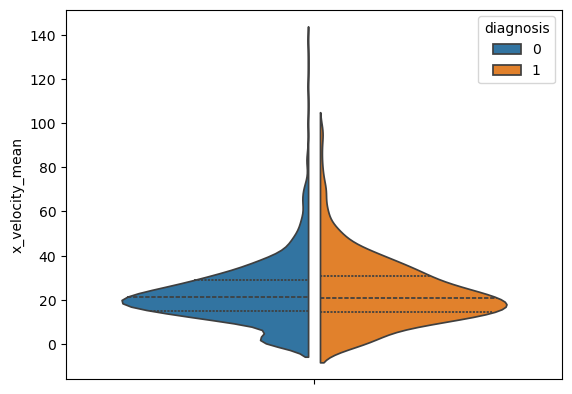

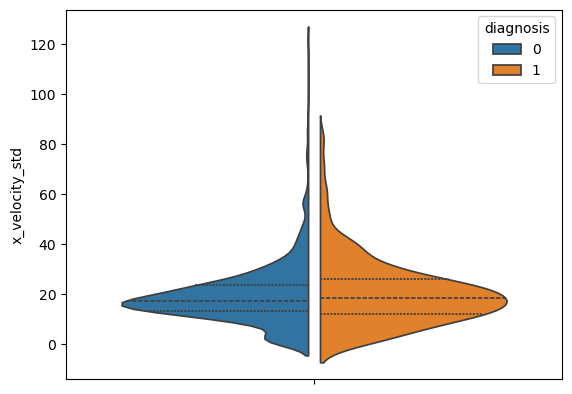

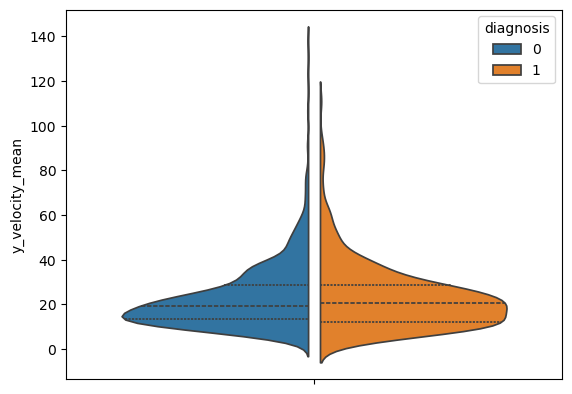

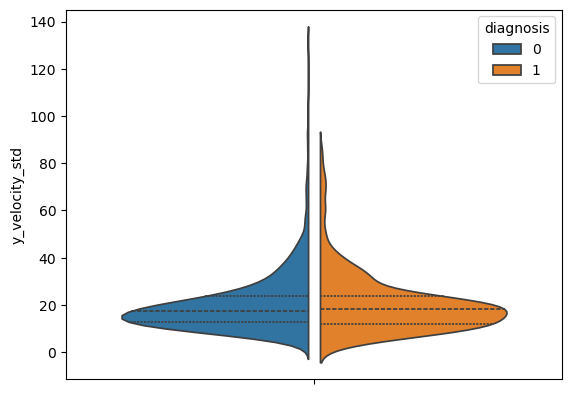

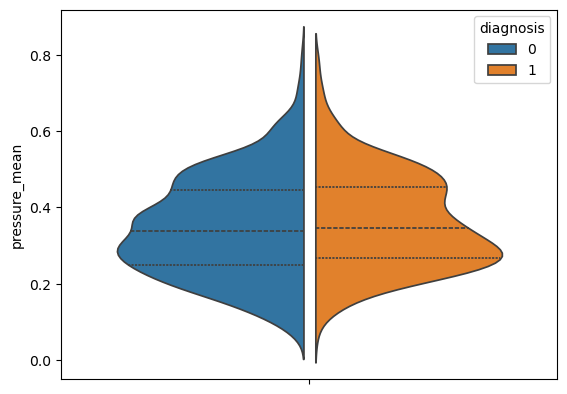

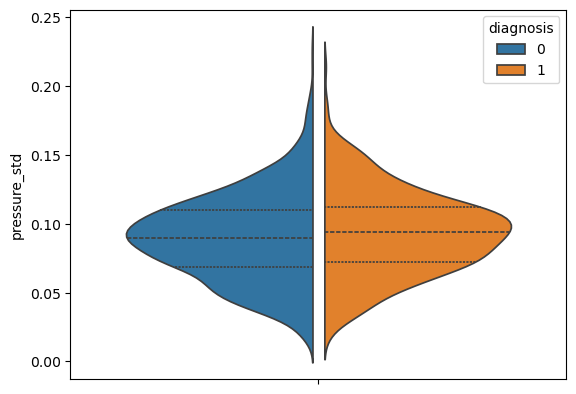

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=df, y="x_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="x_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="y_velocity_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="y_velocity_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="pressure_mean", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()
sns.violinplot(data=df, y="pressure_std", hue = "diagnosis", split =True, gap = 0.06, inner="quartile")
plt.show()

In [ ]:

# Mann-Whitney U test on task 1_1
from scipy.stats import mannwhitneyu

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_1_1 = df_hc_task1_1["x_velocity_mean"]
preLBD_xvel_mean_1_1 = df_preLBD_task1_1["x_velocity_mean"]

stat_xvel_mean_1_1, p_xvel_mean_1_1 = mannwhitneyu(hc_xvel_mean_1_1, preLBD_xvel_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_1_1}, p-value={p_xvel_mean_1_1}")
## X - axis velocity std

hc_xvel_std_1_1 = df_hc_task1_1["x_velocity_std"]
preLBD_xvel_std_1_1 = df_preLBD_task1_1["x_velocity_std"]

stat_xvel_std_1_1, p_xvel_std_1_1 = mannwhitneyu(hc_xvel_std_1_1, preLBD_xvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_1_1}, p-value={p_xvel_std_1_1}")
## Y - axis velocity mean
hc_yvel_mean_1_1 = df_hc_task1_1["y_velocity_mean"]
preLBD_yvel_mean_1_1 = df_preLBD_task1_1["y_velocity_mean"]

stat_yvel_mean_1_1, p_yvel_mean_1_1 = mannwhitneyu(hc_yvel_mean_1_1, preLBD_yvel_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_1_1}, p-value={p_yvel_mean_1_1}")
## Y - axis velocity std
hc_yvel_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_yvel_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_yvel_std_1_1, p_yvel_std_1_1 = mannwhitneyu(hc_yvel_std_1_1, preLBD_yvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_1_1}, p-value={p_yvel_std_1_1}")
## Pressure mean
hc_pressure_mean_1_1 = df_hc_task1_1["pressure_mean"]
preLBD_pressure_mean_1_1 = df_preLBD_task1_1["pressure_mean"]

stat_pressure_mean_1_1, p_pressure_mean_1_1 = mannwhitneyu(hc_pressure_mean_1_1, preLBD_pressure_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_1_1}, p-value={p_pressure_mean_1_1}")
## Pressure std
hc_pressure_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_pressure_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_pressure_std_1_1, p_pressure_std_1_1 = mannwhitneyu(hc_pressure_std_1_1, preLBD_pressure_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_1_1}, p-value={p_pressure_std_1_1}")

Mann-Whitney U Test for X-axis Velocity Mean: U-statistic=2141.0, p-value=0.22830968603668178
Mann-Whitney U Test for X-axis Velocity std: U-statistic=2147.0, p-value=0.21773273706229135
Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic=2130.0, p-value=0.24864075721470347
Mann-Whitney U Test for Y-axis Velocity std: U-statistic=2134.0, p-value=0.2411058964896864
Mann-Whitney U Test for Pressure Mean: U-statistic=1654.0, p-value=0.2930186743258284
Mann-Whitney U Test for Pressure std: U-statistic=2134.0, p-value=0.2411058964896864


In [ ]:


# Mann-Whitney U test whole database

# Whole datbase
## X - axis velocity mean
hc_xvel_mean_1_1 = df_hc_task1_1["x_velocity_mean"]
preLBD_xvel_mean_1_1 = df_preLBD_task1_1["x_velocity_mean"]

stat_xvel_mean_1_1, p_xvel_mean_1_1 = mannwhitneyu(hc_xvel_mean_1_1, preLBD_xvel_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity Mean: U-statistic={stat_xvel_mean_1_1}, p-value={p_xvel_mean_1_1}")
## X - axis velocity std

hc_xvel_std_1_1 = df_hc_task1_1["x_velocity_std"]
preLBD_xvel_std_1_1 = df_preLBD_task1_1["x_velocity_std"]

stat_xvel_std_1_1, p_xvel_std_1_1 = mannwhitneyu(hc_xvel_std_1_1, preLBD_xvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for X-axis Velocity std: U-statistic={stat_xvel_std_1_1}, p-value={p_xvel_std_1_1}")
## Y - axis velocity mean
hc_yvel_mean_1_1 = df_hc_task1_1["y_velocity_mean"]
preLBD_yvel_mean_1_1 = df_preLBD_task1_1["y_velocity_mean"]

stat_yvel_mean_1_1, p_yvel_mean_1_1 = mannwhitneyu(hc_yvel_mean_1_1, preLBD_yvel_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity Mean: U-statistic={stat_yvel_mean_1_1}, p-value={p_yvel_mean_1_1}")
## Y - axis velocity std
hc_yvel_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_yvel_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_yvel_std_1_1, p_yvel_std_1_1 = mannwhitneyu(hc_yvel_std_1_1, preLBD_yvel_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Y-axis Velocity std: U-statistic={stat_yvel_std_1_1}, p-value={p_yvel_std_1_1}")
## Pressure mean
hc_pressure_mean_1_1 = df_hc_task1_1["pressure_mean"]
preLBD_pressure_mean_1_1 = df_preLBD_task1_1["pressure_mean"]

stat_pressure_mean_1_1, p_pressure_mean_1_1 = mannwhitneyu(hc_pressure_mean_1_1, preLBD_pressure_mean_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure Mean: U-statistic={stat_pressure_mean_1_1}, p-value={p_pressure_mean_1_1}")
## Pressure std
hc_pressure_std_1_1 = df_hc_task1_1["y_velocity_std"]
preLBD_pressure_std_1_1 = df_preLBD_task1_1["y_velocity_std"]

stat_pressure_std_1_1, p_pressure_std_1_1 = mannwhitneyu(hc_pressure_std_1_1, preLBD_pressure_std_1_1, alternative='two-sided')

print(f"Mann-Whitney U Test for Pressure std: U-statistic={stat_pressure_std_1_1}, p-value={p_pressure_std_1_1}")